# Ecommerce Purchases Exercise — Solutions

Fake customer purchase dataset (30,000 entries). Customers supply personal
information while buying online or in-store; the client wants answers to a set
of questions about that data.

**Data:** `data/Cust_Purch_FakeData.csv` (20 columns × 30,000 rows).

Each question below is answered with pandas, and the answer is printed in plain
language underneath the code.

**1. Import Pandas and Read the csv file.**

In [1]:
import os

import pandas as pd

# Works both in this repo (data/...) and in Colab where the CSV sits next to the notebook.
CSV_CANDIDATES = [
    "data/Cust_Purch_FakeData.csv",
    "Cust_Purch_FakeData.csv",
    "/content/Cust_Purch_FakeData.csv",
]
csv_path = next((p for p in CSV_CANDIDATES if os.path.exists(p)), None)
if csv_path is None:
    raise FileNotFoundError(
        "Cust_Purch_FakeData.csv not found. Upload it next to the notebook."
    )

df = pd.read_csv(csv_path)
print("Loaded:", csv_path)

Loaded: data/Cust_Purch_FakeData.csv


**2. Its good idea to see how the data look like, display first 5 rows of your data-set.**

In [2]:
df.head()

,prefix,first,last,email,gender,age,company,profession,phone,postal,province,cc_no,cc_exp,cc_type,price(CAD),fav_color,ip,weekday,ampm,date
0,Dr.,Ray,Morton,sebvajom@kol.km,Male,38,Medtronic Inc.,Health Therapist,(987) 619-2695,B6V 3W3,MB,5020000000000230,05/2018,Solo,8.36,Blue,126.23.139.2,Sunday,pm,04/05/1930
1,Miss,Claudia,Rodriquez,acu@jatsot.ug,Female,51,"Ames Department Stores, Inc.",Health Therapist,(356) 736-7352,G7M 5F3,SK,5020000000000230,07/2028,Visa,68.31,Black,106.198.76.211,Tuesday,am,12/20/1926
2,Miss,Harry,Meyer,zuz@lo.wf,Female,51,CSX Corp.,Political Scientist,(539) 246-1806,A0Z 6P9,NS,6300000000000000,02/2023,Switch,34.65,Black,186.150.187.29,Wednesday,pm,08/20/1931
3,Miss,Edith,Gilbert,hansohsi@jupec.md,Female,55,Murphy Oil Corporation,Transportation Manager,(984) 962-7494,P9I 9H3,YT,3530000000000000,02/2028,Maestro,64.59,White,80.140.57.161,Saturday,am,06/18/2001
4,Dr.,Lura,Murphy,webediti@je.st,Female,20,PETsMART Inc,Statistician,(902) 568-9748,S1A 6K0,ON,4030000000000000,10/2025,Diners Club International,20.83,Yellow,211.103.43.41,Friday,pm,06/14/2045


**3. How many entries your data have? Can you tell the no. of columns in your data?**

In [3]:
df.info()

rows, cols = df.shape
print(f"\nThe data has {rows} entries (rows) and {cols} columns.")

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   prefix      30000 non-null  str    
 1   first       30000 non-null  str    
 2   last        30000 non-null  str    
 3   email       30000 non-null  str    
 4   gender      30000 non-null  str    
 5   age         30000 non-null  int64  
 6   company     30000 non-null  str    
 7   profession  30000 non-null  str    
 8   phone       30000 non-null  str    
 9   postal      30000 non-null  str    
 10  province    30000 non-null  str    
 11  cc_no       30000 non-null  int64  
 12  cc_exp      30000 non-null  str    
 13  cc_type     30000 non-null  str    
 14  price(CAD)  30000 non-null  float64
 15  fav_color   30000 non-null  str    
 16  ip          30000 non-null  str    
 17  weekday     30000 non-null  str    
 18  ampm        30000 non-null  str    
 19  date        30000 non-null  str    


**4. What are the max and min ages of your customer? Can you find mean of your customer?**

In [4]:
print("Max. age of the customer is: ", df["age"].max())
print("Min. age of the customer is: ", df["age"].min())
print("Avg. age of the customer is: ", df["age"].mean())

Max. age of the customer is:  65
Min. age of the customer is:  18
Avg. age of the customer is:  41.550066666666666


**5. What are the three most common customer's names?**

`value_counts()` returns the counts of unique values in descending order, so the
first three entries are the three most common first names.

In [5]:
top3_names = df["first"].value_counts().head(3)
print(top3_names)
print("\nThe three most common names are:", ", ".join(top3_names.index))

first
Willie     130
Francis    124
Eula        86
Name: count, dtype: int64

The three most common names are: Willie, Francis, Eula


**6. Two customers have the same phone number, can you find those customers?**

In [6]:
# First, find which phone number appears twice.
phone_counts = df["phone"].value_counts()
print(phone_counts.head(2))

duplicate_phone = phone_counts[phone_counts > 1].index[0]
print("\nThe phone number used twice is:", duplicate_phone)

phone
(263) 382-8004    2
(987) 619-2695    1
Name: count, dtype: int64

The phone number used twice is: (263) 382-8004


In [7]:
# Now that we know the phone number, let's see the two customers.
df[df["phone"] == duplicate_phone]

,prefix,first,last,email,gender,age,company,profession,phone,postal,province,cc_no,cc_exp,cc_type,price(CAD),fav_color,ip,weekday,ampm,date
15,Mrs.,Lilly,Tyler,kofadu@itohi.tf,Female,38,CSX Corp.,Structural Engineer,(263) 382-8004,V7K 1E3,ON,30000000000000,11/2022,Diners Club Carte Blanche,9.61,Yellow,74.124.37.227,Saturday,am,03/30/1985
16,Mrs.,Peter,Cain,megkosig@anazeor.gn,Male,27,Campbell Soup Co.,Insurance Adjuster,(263) 382-8004,E8T 2B4,YT,3530000000000000,03/2024,Solo,13.74,Black,25.207.141.135,Tuesday,am,08/05/1950


**7. How many customers have profession "Structural Engineer"?**

In [8]:
structural_engineers = df[df["profession"] == "Structural Engineer"]
print("Customers with profession 'Structural Engineer':", len(structural_engineers))

Customers with profession 'Structural Engineer': 87


**8. How many male customers are 'Structural Engineer'?**

In [9]:
male_se = df[(df["profession"] == "Structural Engineer") & (df["gender"] == "Male")]
print("Male 'Structural Engineer' customers:", len(male_se))

Male 'Structural Engineer' customers: 43


**9. Find out the female Structural Engineers from province Alberta (AB)?**

In [10]:
female_se_ab = df[
    (df["profession"] == "Structural Engineer")
    & (df["gender"] == "Female")
    & (df["province"] == "AB")
]
print("Female Structural Engineers in AB:", len(female_se_ab))
female_se_ab

Female Structural Engineers in AB: 4


,prefix,first,last,email,gender,age,company,profession,phone,postal,province,cc_no,cc_exp,cc_type,price(CAD),fav_color,ip,weekday,ampm,date
8858,Dr.,Roy,Stanley,apiunvo@ehasom.ir,Female,39,Cincinnati Financial Corp.,Structural Engineer,(876) 758-2929,N5A 6L2,AB,6300000000000000,02/2022,InstaPayment,31.86,Red,165.249.159.57,Sunday,pm,12/25/1903
9058,Mr.,Lora,Kennedy,dennap@rabac.se,Female,51,BJ Services Company,Structural Engineer,(305) 786-6959,N3R 4B7,AB,201000000000000,06/2019,Diners Club United States & Canada,53.29,Black,42.216.243.206,Thursday,pm,06/06/2028
24736,Mrs.,Nell,Richards,dob@me.ki,Female,18,Telephone & Data Systems Inc,Structural Engineer,(262) 681-5018,N3Y 3G2,AB,347000000000000,07/2028,American Express,76.28,Blue,91.16.30.156,Wednesday,pm,07/14/1951
29865,Mrs.,Don,McDaniel,naf@zudu.bj,Female,37,Anadarko Petroleum Corporation,Structural Engineer,(238) 789-2825,B4A 8Q9,AB,5610000000000000,12/2022,Mastercard,62.71,Blue,162.233.117.142,Sunday,pm,11/03/1989


**10. What is the max, min and average spending?**

In [11]:
print("Max. spending: ", df["price(CAD)"].max())
print("Min. spending: ", df["price(CAD)"].min())
print("Avg. spending: ", df["price(CAD)"].mean())

Max. spending:  100.0
Min. spending:  0.0
Avg. spending:  49.990775


**11. Who did not spend anything? Company wants to send a deal to encourage the customer to buy stuff!**

In [12]:
no_spend = df[df["price(CAD)"] == 0]
print("Customers who spent nothing:", len(no_spend))
no_spend

Customers who spent nothing: 2


,prefix,first,last,email,gender,age,company,profession,phone,postal,province,cc_no,cc_exp,cc_type,price(CAD),fav_color,ip,weekday,ampm,date
5320,Dr.,Bruce,Bryan,ru@pubuspuh.cl,Male,59,Wal-Mart Stores Inc,Engineer Technician,(709) 446-8317,H6H 3Y0,NU,201000000000000,04/2024,Bankcard,0.0,White,82.70.62.64,Wednesday,am,12/11/1900
10597,Mrs.,Flora,Clark,wad@me.com,Female,27,MetLife Inc.,Cruise Director,(775) 373-6590,B2U 8K6,NB,30100000000000,05/2020,Diners Club Carte Blanche,0.0,Red,231.156.15.63,Thursday,pm,08/22/1904


**12. As a loyalty reward, company wants to send thanks coupon to those who spent 100 CAD or more, please find out the customers?**

In [13]:
big_spenders = df[df["price(CAD)"] >= 100]
print("Customers who spent 100 CAD or more:", len(big_spenders))
big_spenders

Customers who spent 100 CAD or more: 3


,prefix,first,last,email,gender,age,company,profession,phone,postal,province,cc_no,cc_exp,cc_type,price(CAD),fav_color,ip,weekday,ampm,date
76,Mrs.,Gregory,Brown,hav@jek.gs,Female,31,"E*Trade Group, Inc.",Novelist,(625) 537-8923,X3S 4Q2,PE,6010000000000000,04/2018,Visa,100.0,Green,212.100.18.95,Monday,am,10/23/2063
21093,Mrs.,Cody,Christensen,get@jovu.ag,Male,28,National City Corp.,Hospital Administrator,(261) 737-3292,X0S 1O5,PE,201000000000000,03/2024,JCB,100.0,Green,168.48.19.165,Wednesday,pm,03/28/1955
24385,Miss,Lizzie,Dixon,goh@tuwjaz.gd,Female,38,FleetBoston Financial Co.,Compensation Analyst,(989) 239-1752,V8X 9V6,NB,6300000000000000,07/2019,Bankcard,100.0,Blue,140.87.99.78,Saturday,pm,03/03/1983


**13. How many emails are associated with this credit card number '5020000000000230'?**

In [14]:
card_emails = df[df["cc_no"] == 5020000000000230]["email"]
print(card_emails)
print("\nNumber of emails on this card:", card_emails.count())

0    sebvajom@kol.km
1      acu@jatsot.ug
Name: email, dtype: str

Number of emails on this card: 2


**14. We need to send new cards to the customers well before the expire, how many cards are expiring in 2019?**

`sum()` adds up the `True` values of the boolean mask (the count of matches),
while `count()` on that same mask counts every row — including the `False` ones.

In [15]:
expiring_2019 = df["cc_exp"].apply(lambda exp: exp.split("/")[1] == "2019")

print("Cards expiring in 2019 (sum): ", expiring_2019.sum())
print("Rows checked in total (count):", expiring_2019.count())

Cards expiring in 2019 (sum):  2684
Rows checked in total (count): 30000


**15. How many people use Visa as their Credit Card Provider?**

In [16]:
visa_users = (df["cc_type"] == "Visa").sum()
print("Customers using Visa:", visa_users)

Customers using Visa: 1721


**16. Can you find the customer who spent 100 CAD using Visa?**

In [17]:
visa_100 = df[(df["cc_type"] == "Visa") & (df["price(CAD)"] == 100)]
print("Customers who spent 100 CAD with Visa:", len(visa_100))
visa_100

Customers who spent 100 CAD with Visa: 1


,prefix,first,last,email,gender,age,company,profession,phone,postal,province,cc_no,cc_exp,cc_type,price(CAD),fav_color,ip,weekday,ampm,date
76,Mrs.,Gregory,Brown,hav@jek.gs,Female,31,"E*Trade Group, Inc.",Novelist,(625) 537-8923,X3S 4Q2,PE,6010000000000000,04/2018,Visa,100.0,Green,212.100.18.95,Monday,am,10/23/2063


**17. What are two most common professions?**

In [18]:
top2_professions = df["profession"].value_counts().head(2)
print(top2_professions)
print("\nThe two most common professions are:", ", ".join(top2_professions.index))

profession
Preschool Teacher       112
Distribution Manager    107
Name: count, dtype: int64

The two most common professions are: Preschool Teacher, Distribution Manager


**18. Can you tell the top 5 most popular email providers? (e.g. gmail.com, yahoo.com, etc...)**

In [19]:
providers = df["email"].apply(lambda email: email.split("@")[1])
top5_providers = providers.value_counts().head(5)
print(top5_providers)

email
gmail.com      1687
me.com         1676
outlook.com    1664
live.com       1660
hotmail.com    1659
Name: count, dtype: int64


**19. Is there any customer who is using email with "am.edu"?**

Split the email address at `@` inside a `lambda` and compare the domain part.

In [20]:
am_edu = df[df["email"].apply(lambda email: email.split("@")[1] == "am.edu")]
print("Customers using an 'am.edu' email:", len(am_edu))
am_edu

Customers using an 'am.edu' email: 1


,prefix,first,last,email,gender,age,company,profession,phone,postal,province,cc_no,cc_exp,cc_type,price(CAD),fav_color,ip,weekday,ampm,date
150,Miss,Loretta,Fletcher,barit@am.edu,Female,48,York International Corp,Rehabilitation Counselor,(323) 279-8038,E5X 8L0,QC,6330000000000000,05/2021,Diners Club United States & Canada,97.26,White,147.57.240.225,Monday,am,11/07/2066


**20. Which day of the week, the store gets more customers?**

In [21]:
weekday_counts = df["weekday"].value_counts()
print(weekday_counts)
print(
    f"\nThe store gets the most customers on {weekday_counts.index[0]} "
    f"({weekday_counts.iloc[0]} customers)."
)

weekday
Saturday     4376
Wednesday    4365
Thursday     4327
Friday       4316
Monday       4216
Sunday       4213
Tuesday      4187
Name: count, dtype: int64

The store gets the most customers on Saturday (4376 customers).


## Bonus: a couple of quick visualizations

The questions above are answered numerically; these two charts make the busiest
weekday and the spending distribution easier to read at a glance.

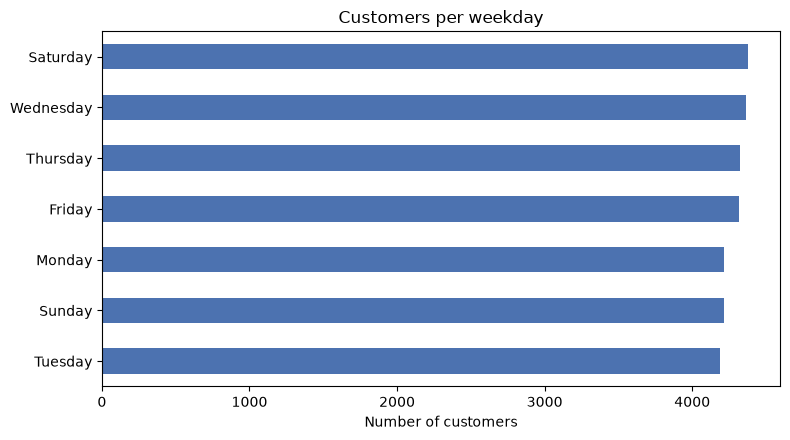

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
weekday_counts.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Customers per weekday")
ax.set_xlabel("Number of customers")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig("chart_customers_per_weekday.png", dpi=110)
plt.show()

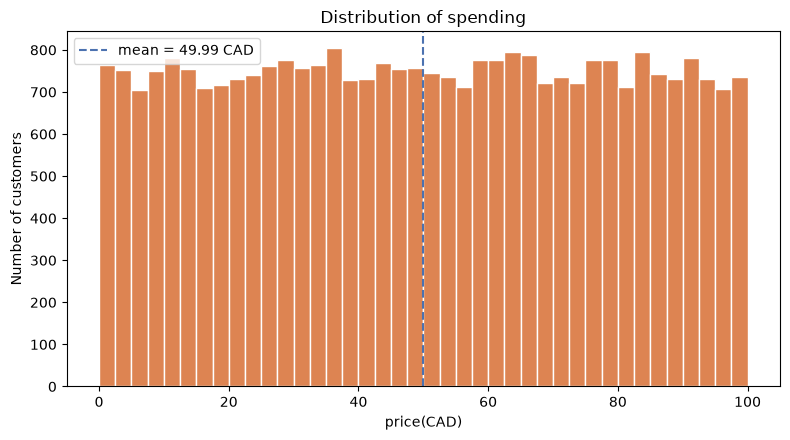

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["price(CAD)"], bins=40, color="#DD8452", edgecolor="white")
ax.axvline(df["price(CAD)"].mean(), color="#4C72B0", linestyle="--",
           label=f"mean = {df['price(CAD)'].mean():.2f} CAD")
ax.set_title("Distribution of spending")
ax.set_xlabel("price(CAD)")
ax.set_ylabel("Number of customers")
ax.legend()
fig.tight_layout()
fig.savefig("chart_spending_distribution.png", dpi=110)
plt.show()

# Excellent work!